# Critical Clearing Time Mapping

The critical clearing time (CCT) is defined as the maximum duration for
which a fault can persist before the system loses synchronism. It is a
fundamental metric in transient stability assessment, where a shorter CCT
indicates a more vulnerable operating condition. By mapping the CCT across
all buses in a network, the spatial distribution of stability margins can
be revealed.

In this notebook, the CCT is computed for every bus in the Kundur two-area
system, which consists of four GENROU generators equipped with AVR and
governor controls. The procedure is as follows:

1. A three-phase fault is applied at each bus, and the clearing time is
   swept over a range of values.
2. Each scenario is classified as stable, unstable, or non-convergent
   using the built-in rotor angle separation criterion.
3. The stability boundary is visualized through a heatmap of maximum
   angle separation, a network topology diagram colored by CCT, and
   rotor angle trajectories at the stability boundary.

The `TDS.reinit()` API is utilized to reset the simulation to its
post-initialization state between scenarios, thereby avoiding the overhead
of reloading the system for each clearing time.

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.patches as mpatches

import andes

andes.config_logger(stream_level=50)

## System Setup

The Kundur two-area system consists of two symmetrical areas connected by
a weak tie line, with two GENROU generators in each area. The built-in
case includes a line-trip event (`Toggle`) at $t = 2$ s, which is disabled
here so that the fault remains the sole disturbance.

Each bus is classified by its role in the network: generator buses (G)
host synchronous machines, tie-line buses (T) form the inter-area corridor,
and load buses (L) represent intermediate connection points. This
classification is used to annotate the visualizations that follow.

In [2]:
case_path = andes.get_case("kundur/kundur_full.xlsx")
ss_ref = andes.load(case_path, no_output=True)
ss_ref.Toggle.u.v[0] = 0  # disable built-in line trip
ss_ref.PFlow.run()

bus_idxs = list(ss_ref.Bus.idx.v)
gen_idxs = list(ss_ref.GENROU.idx.v)
gen_buses = list(ss_ref.GENROU.bus.v)

# Classify buses by role
bus_type = {}
for b in bus_idxs:
    if b in gen_buses:
        bus_type[b] = "gen"
    elif b in [7, 8, 9]:  # tie-line buses
        bus_type[b] = "tie"
    else:
        bus_type[b] = "load"

gen_info = pd.DataFrame({
    "gen_idx": gen_idxs,
    "bus": gen_buses,
    "M": ss_ref.GENROU.M.v,
})
gen_info

,gen_idx,bus,M
0,1,1,117.00
1,2,2,117.00
2,3,3,111.15
3,4,4,111.15


## CCT Sweep

A three-phase fault with reactance $x_f = 10^{-4}$ p.u. is applied at
$t = 1$ s on each bus. The clearing time is swept from 25 ms to 675 ms
in 25 ms increments. For each fault bus, the system is loaded once, and
`TDS.reinit()` is called between clearing-time values to restore the
post-initialization state without reloading.

Each scenario is classified into one of three outcomes:

- **Stable**: the simulation completes and all rotor angle separations
  remain below 180 degrees.
- **Unstable**: the built-in `deltadelta` criterion detects a rotor angle
  separation exceeding 180 degrees, and the simulation is terminated early.
- **Non-convergent**: the Newton solver fails to converge and the time step
  is reduced to zero.

The maximum rotor angle separation (in degrees) is recorded for each
scenario to produce a continuous stability map.

In [3]:
tc_values = np.arange(0.025, 0.70, 0.025)
n_bus = len(bus_idxs)
n_tc = len(tc_values)

outcome = np.full((n_bus, n_tc), -1, dtype=int)
max_sep_deg = np.full((n_bus, n_tc), np.nan)

for i, fbus in enumerate(bus_idxs):
    ss = andes.load(case_path, setup=False, no_output=True)
    ss.Toggle.u.v[0] = 0
    ss.add("Fault", bus=fbus, tf=1.0, tc=1.0 + tc_values[0], xf=1e-4)
    ss.setup()
    ss.config.warn_abnormal = 0

    ss.PFlow.run()
    ss.TDS.config.tf = 8.0
    ss.TDS.config.no_tqdm = 1
    ss.TDS.init()

    for j, tc in enumerate(tc_values):
        ss.TDS.reinit()
        ss.Fault.tc.v[0] = 1.0 + tc

        ss.switch_dict.clear()
        ss.store_switch_times(ss.exist.pflow_tds)

        ss.TDS.config.tf = 8.0
        ss.TDS.run(no_summary=True)

        # Extract max rotor angle separation
        delta = ss.dae.ts.x[:, ss.GENROU.delta.a]
        sep = np.rad2deg(np.max(delta, axis=1) - np.min(delta, axis=1))
        max_sep_deg[i, j] = sep.max()

        if not ss.TDS.busted:
            outcome[i, j] = 0
        elif "criteria" in ss.TDS.err_msg.lower():
            outcome[i, j] = 1
        else:
            outcome[i, j] = 2

## Stability Boundary

The heatmap below displays the maximum rotor angle separation for each
(bus, clearing time) pair. Buses are sorted by their CCT values, with the
most vulnerable buses at the top. Green regions correspond to small angle
excursions (stable operation), while red regions indicate separations
approaching or exceeding the 180-degree threshold. The white dashed contour
marks the 90-degree separation level, and white dots indicate the CCT
boundary for each bus.

Bus labels are color-coded by type: generator (G, red), tie-line (T, blue),
and load (L, green).

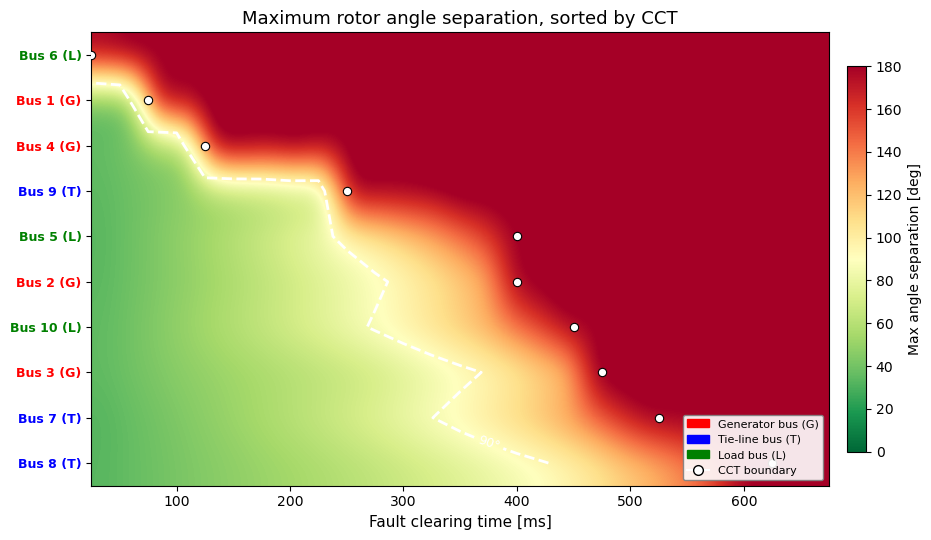

In [10]:
# Compute CCT per bus
cct = np.full(n_bus, np.nan)
for i in range(n_bus):
    fail_idx = np.where(outcome[i] > 0)[0]
    if len(fail_idx) > 0:
        cct[i] = tc_values[fail_idx[0]]
    else:
        cct[i] = tc_values[-1]

# Cap non-convergent cells at threshold for smooth plotting
plot_data = max_sep_deg.copy()
plot_data[outcome == 2] = 180.0

# Sort buses by CCT (most vulnerable at top)
sort_order = np.argsort(cct)
plot_sorted = plot_data[sort_order]
cct_sorted = cct[sort_order]
bus_sorted = [bus_idxs[k] for k in sort_order]
type_sorted = [bus_type[bus_idxs[k]] for k in sort_order]

fig, ax = plt.subplots(figsize=(10, 5.5))

im = ax.imshow(
    plot_sorted, aspect="auto", cmap="RdYlGn_r",
    extent=[tc_values[0] * 1000, tc_values[-1] * 1000,
            n_bus - 0.5, -0.5],
    interpolation="bicubic", vmin=0, vmax=180,
)

# Overlay 90-degree contour
tc_grid, bus_grid = np.meshgrid(tc_values * 1000, np.arange(n_bus))
cs = ax.contour(tc_grid, bus_grid, plot_sorted,
                levels=[90], colors=["white"],
                linewidths=2.0, linestyles="--")
ax.clabel(cs, fmt="90°", fontsize=9, colors="white")

# Mark CCT boundary with white dots
for idx_i in range(n_bus):
    ax.plot(cct_sorted[idx_i] * 1000, idx_i, "o",
            color="white", markersize=6, markeredgecolor="k",
            markeredgewidth=0.8, zorder=5)

# Color-coded bus type labels
type_marker = {"gen": "G", "tie": "T", "load": "L"}
type_color = {"gen": "red", "tie": "blue", "load": "green"}
ylabels = [f"Bus {b} ({type_marker[type_sorted[k]]})"
           for k, b in enumerate(bus_sorted)]

ax.set_yticks(range(n_bus))
ax.set_yticklabels(ylabels, fontsize=9)
for tick_label, t in zip(ax.get_yticklabels(), type_sorted):
    tick_label.set_color(type_color[t])
    tick_label.set_fontweight("bold")

ax.set_xlabel("Fault clearing time [ms]", fontsize=11)
ax.set_title("Maximum rotor angle separation, sorted by CCT", fontsize=13)

cb = plt.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
cb.set_label("Max angle separation [deg]", fontsize=10)

legend_handles = [
    mpatches.Patch(color=type_color["gen"], label="Generator bus (G)"),
    mpatches.Patch(color=type_color["tie"], label="Tie-line bus (T)"),
    mpatches.Patch(color=type_color["load"], label="Load bus (L)"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="white",
               markeredgecolor="k", markersize=7, label="CCT boundary"),
]
ax.legend(handles=legend_handles, loc="lower right", fontsize=8,
          framealpha=0.9, edgecolor="gray")

plt.tight_layout()

## Spatial Distribution of CCT

The network topology diagram below maps the CCT values onto the physical
layout of the Kundur two-area system. Each bus is colored according to its
CCT, with the value annotated below the node. Generator buses are
represented by squares, and non-generator buses by circles.

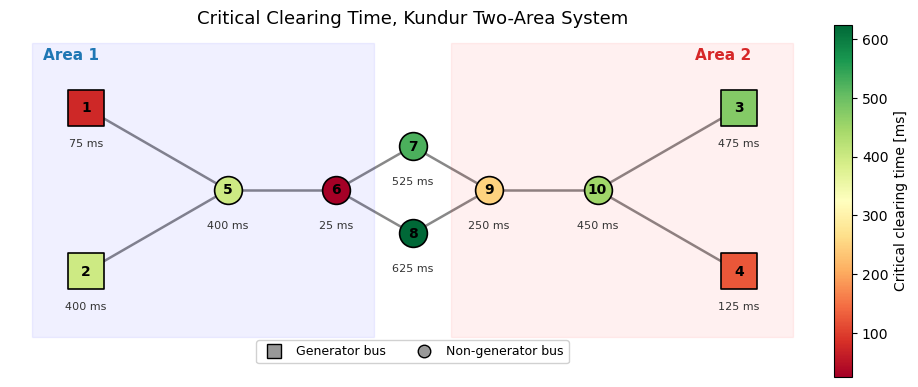

In [5]:
# Kundur two-area layout
bus_pos = {
    1: (0.5, 2.0),   2: (0.5, 0.5),
    3: (6.5, 2.0),   4: (6.5, 0.5),
    5: (1.8, 1.25),  6: (2.8, 1.25),
    7: (3.5, 1.65),  8: (3.5, 0.85),
    9: (4.2, 1.25),  10: (5.2, 1.25),
}

branches = [
    (1, 5), (2, 5), (5, 6), (6, 7), (6, 8),
    (7, 9), (8, 9), (9, 10), (10, 3), (10, 4),
]

cct_dict = {bus_idxs[i]: cct[i] for i in range(n_bus)}
cct_vals = np.array([cct_dict[b] for b in bus_idxs])

fig, ax = plt.subplots(figsize=(10, 5))

for b1, b2 in branches:
    x = [bus_pos[b1][0], bus_pos[b2][0]]
    y = [bus_pos[b1][1], bus_pos[b2][1]]
    ax.plot(x, y, "-", color="#888888", linewidth=1.8, zorder=1)

cmap = plt.cm.RdYlGn
norm = Normalize(vmin=cct_vals.min() * 1000, vmax=cct_vals.max() * 1000)

for b in bus_idxs:
    x, y = bus_pos[b]
    c = cmap(norm(cct_dict[b] * 1000))
    size = 700 if b in gen_buses else 400
    marker = "s" if b in gen_buses else "o"
    ax.scatter(x, y, s=size, c=[c], marker=marker,
               edgecolors="k", linewidths=1.2, zorder=3)
    ax.annotate(f"{b}", (x, y), fontsize=10, fontweight="bold",
                ha="center", va="center", zorder=4)
    ax.annotate(f"{cct_dict[b]*1000:.0f} ms", (x, y - 0.28),
                fontsize=8, ha="center", va="top", color="#333333", zorder=4)

# Area shading
ax.fill([0.0, 3.15, 3.15, 0.0], [-0.1, -0.1, 2.6, 2.6],
        alpha=0.06, color="blue")
ax.fill([3.85, 7.0, 7.0, 3.85], [-0.1, -0.1, 2.6, 2.6],
        alpha=0.06, color="red")
ax.text(0.1, 2.45, "Area 1", fontsize=11, color="#1f77b4", fontweight="bold")
ax.text(6.1, 2.45, "Area 2", fontsize=11, color="#d62728", fontweight="bold")

sm = ScalarMappable(cmap=cmap, norm=norm)
cb = plt.colorbar(sm, ax=ax, shrink=0.75, pad=0.02)
cb.set_label("Critical clearing time [ms]", fontsize=10)

legend_handles = [
    plt.Line2D([0], [0], marker="s", color="w", markerfacecolor="#999",
               markeredgecolor="k", markersize=10, label="Generator bus"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="#999",
               markeredgecolor="k", markersize=9, label="Non-generator bus"),
]
ax.legend(handles=legend_handles, loc="lower center", fontsize=9,
          framealpha=0.9, ncol=2)

ax.set_xlim(-0.2, 7.2)
ax.set_ylim(-0.4, 2.7)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("Critical Clearing Time, Kundur Two-Area System", fontsize=13)

plt.tight_layout()

The results reveal a consistent ordering: tie-line midpoint buses (7, 8)
have the longest CCTs, followed by interior generator and load buses
(2, 3, 5, 10), then boundary generator buses (1, 4), and finally the
Area 1 border bus (6) with the shortest CCT at 25 ms. A notable asymmetry
exists between the two area border buses: bus 6 and bus 9 occupy
topologically symmetric positions, yet their CCTs differ by an order of
magnitude. The source of this asymmetry is not immediately apparent from
the topology alone and likely involves the pre-fault tie-line power flow
direction, specific line impedances, and load distribution.

## Rotor Angle Trajectories at the Stability Boundary

To illustrate the transition from stable to unstable behavior, rotor angle
trajectories are plotted for a fault at bus 8 at four clearing times that
straddle the CCT. The angles are expressed relative to the center of
inertia (COI), which removes the common-mode swing and isolates the
inter-machine separation.

For the final (unstable) case, the stability criterion is disabled so that
the simulation continues beyond the point of instability, thereby
capturing the full divergent trajectory.

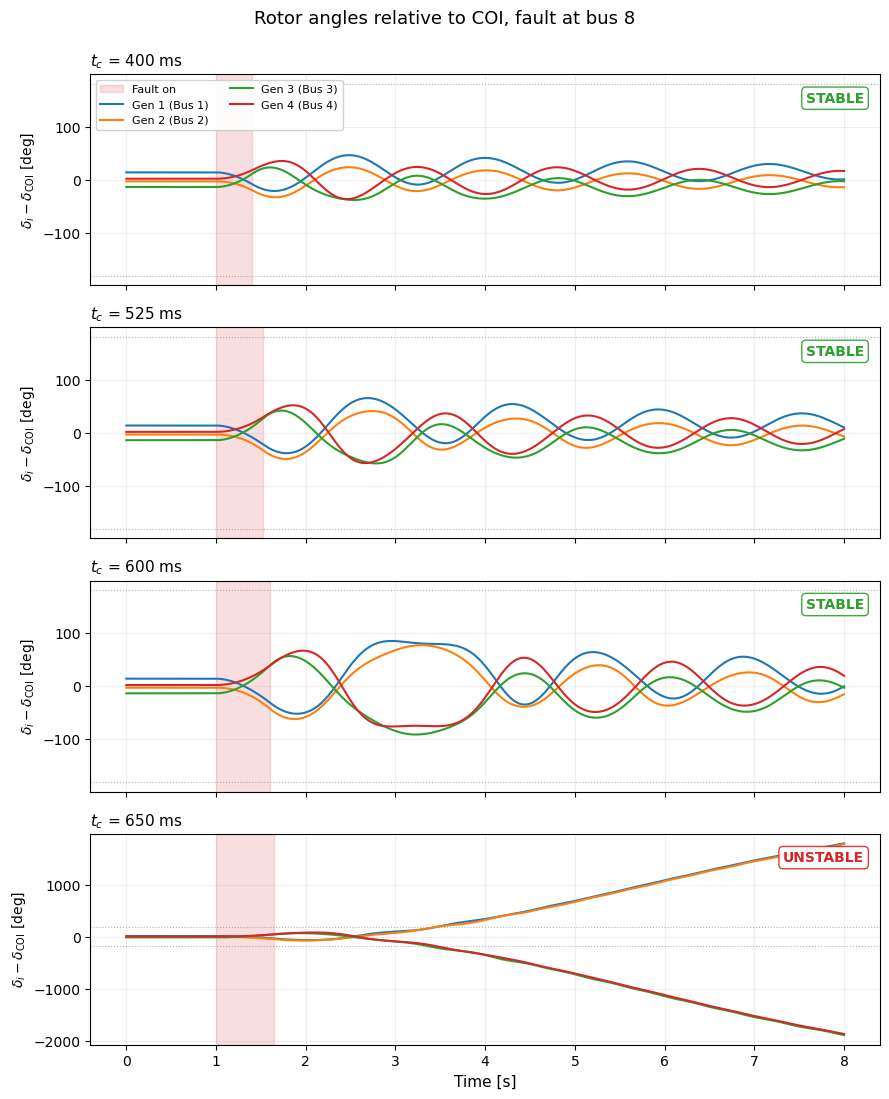

In [6]:
demo_bus = 8
demo_tcs = [0.400, 0.525, 0.600, 0.650]
demo_results = {}
M_vals = np.array(ss_ref.GENROU.M.v)

for tc in demo_tcs:
    ss = andes.load(case_path, setup=False, no_output=True)
    ss.Toggle.u.v[0] = 0
    ss.add("Fault", bus=demo_bus, tf=1.0, tc=1.0 + tc, xf=1e-4)
    ss.setup()
    ss.config.warn_abnormal = 0
    ss.PFlow.run()
    ss.TDS.config.tf = 8.0
    ss.TDS.config.no_tqdm = 1
    # Disable criteria for the last case to capture full divergent trajectory
    if tc == demo_tcs[-1]:
        ss.TDS.config.criteria = 0
    ss.TDS.run()
    delta_df = ss.TDS.get_timeseries(ss.GENROU.delta)
    demo_results[tc] = np.rad2deg(delta_df)

# Compute COI-relative angles
coi_results = {}
for tc, df in demo_results.items():
    delta_arr = df.values
    coi = np.average(delta_arr, axis=1, weights=M_vals)
    relative = delta_arr - coi[:, None]
    coi_results[tc] = pd.DataFrame(relative, index=df.index, columns=df.columns)

gen_labels = [f"Gen {idx} (Bus {b})" for idx, b in zip(gen_idxs, gen_buses)]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

fig, axes = plt.subplots(4, 1, figsize=(9, 11), sharex=True, sharey=False)

# Share y-axis among the first 3 stable panels; let the last panel float
for ax in axes[1:3]:
    ax.sharey(axes[0])

for ax, tc in zip(axes, demo_tcs):
    df = coi_results[tc]

    ax.axvspan(1.0, 1.0 + tc, alpha=0.15, color="#d62728", zorder=0,
               label="Fault on" if tc == demo_tcs[0] else None)

    ax.axhline(180, color="gray", linewidth=0.8, linestyle=":", alpha=0.6)
    ax.axhline(-180, color="gray", linewidth=0.8, linestyle=":", alpha=0.6)

    for k, col in enumerate(df.columns):
        ax.plot(df.index, df[col], linewidth=1.5, color=colors[k],
                label=gen_labels[k] if tc == demo_tcs[0] else None)

    max_sep = df.max().max() - df.min().min()
    if max_sep < 180:
        status_text, status_color = "STABLE", "#2ca02c"
    else:
        status_text, status_color = "UNSTABLE", "#d62728"

    ax.text(0.98, 0.92, status_text, transform=ax.transAxes,
            fontsize=10, fontweight="bold", color=status_color,
            ha="right", va="top",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      edgecolor=status_color, alpha=0.9))

    ax.set_title(f"$t_c$ = {tc*1000:.0f} ms", fontsize=11, loc="left")
    ax.set_ylabel(r"$\delta_i - \delta_{\mathrm{COI}}$ [deg]", fontsize=10)
    ax.grid(True, alpha=0.2)

axes[-1].set_xlabel("Time [s]", fontsize=11)
axes[0].legend(loc="upper left", fontsize=8, ncol=2, framealpha=0.9)

fig.suptitle(f"Rotor angles relative to COI, fault at bus {demo_bus}",
             fontsize=13, y=0.995)
plt.tight_layout()

The four panels confirm the expected transition from stable to unstable
behavior. For clearing times well below the CCT, the rotor angles undergo
damped oscillations relative to the COI and converge to a new equilibrium.
As the clearing time approaches the CCT, the oscillation amplitude
increases and the return to equilibrium becomes slower. Beyond the CCT,
the generators separate irreversibly, indicating loss of synchronism.

## Extensions

Several directions can be pursued to extend this example:

- **Fault severity**: the fault reactance $x_f$ can be increased to model
  less severe faults, and the resulting shift of the CCT boundary can be
  observed.
- **Line trip protection**: the built-in `Toggle` event can be re-enabled
  to simulate a fault cleared by tripping a line, which is the standard
  protection scheme in practice.
- **Load level sweep**: all loads can be scaled by a common factor, and
  the CCT map can be recomputed to study how loading affects transient
  stability margins.
- **Machine learning classifier**: the (bus, clearing time, outcome) data
  can be used as labeled training samples for a classifier that predicts
  stability from pre-fault features alone.

In [7]:
!andes misc -C

No output file found in the working directory.
